### Import necessary libraries

In [21]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt
import statistics
from scipy import stats
from scipy.stats import shapiro, normaltest
from colorama import Fore
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from scipy.stats import norm


# Read in data

### Decide if splitting sets or not

In [330]:
split = True

if split:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data_split.csv")
    raw_df.set_index('subject_trial', inplace=True)
else:
    raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")
    raw_df.set_index('subject', inplace=True)

### Decide for all or only small

In [331]:
small_only = True

if small_only:
    raw_df = raw_df.drop(raw_df.filter(like='big', axis=1), axis=1)

print(raw_df.shape[1])

15


### Plot all the raw data

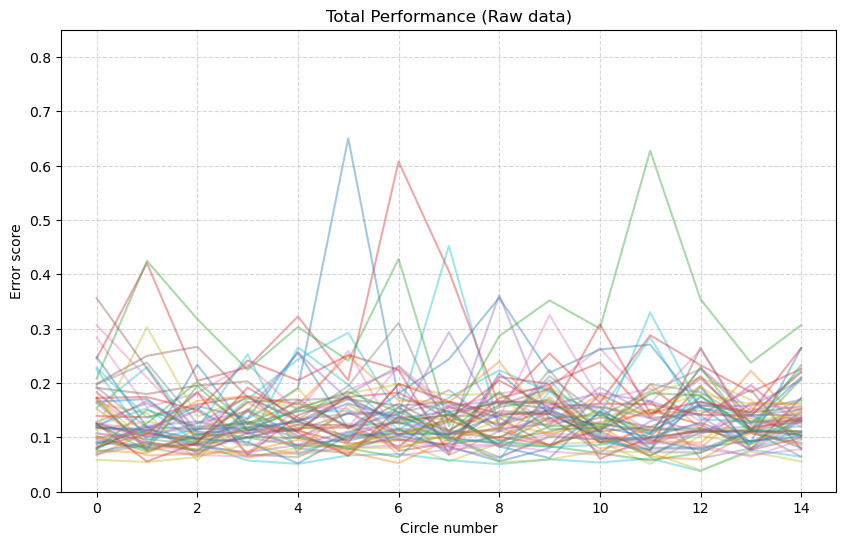

In [332]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Clean up the data by removing outliers

In [333]:
std_dev = 2.5 # how many standard deviations from the mean data can be

# calculate z scores
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# replace values with NaN if they’re more than determined standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > std_dev)

# fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)

#### Visualize cleaned up data

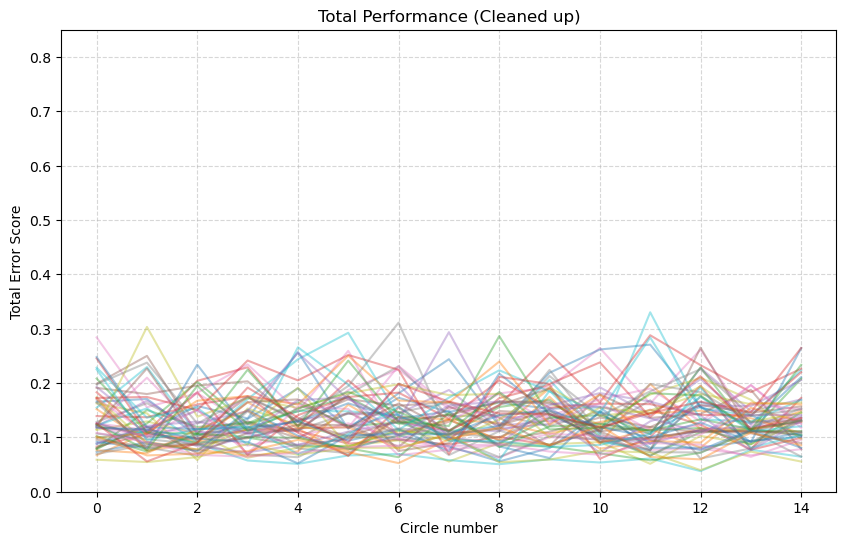

In [334]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(0, raw_df.shape[1]), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number")
plt.ylabel("Total Error Score")
plt.ylim(0, 0.85)
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# Determine percentage change at various window sizes

## Make function to calculate the change

In [335]:
def get_change(start, end):
    difference = end - start
    change = difference / start
    percent_change = change * 100
    return percent_change

## Calculate each percentage change

In [364]:
if not small_only:
    window_sizes = [4, 8, 12, 16, 20]
else:
    window_sizes = [3, 5, 7, 9, 11, 13, 15]

percent_dict = {}

for window in window_sizes:
    all_percents = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            start_val = errors[start]

            end_val = errors[start + window - 1]

            all_percents.append(get_change(start_val, end_val))

    percent_dict[window] = np.array(all_percents)

### Plot each percentage change

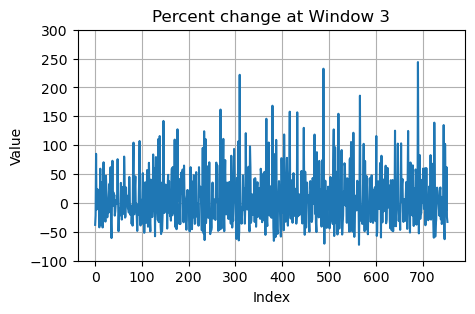

Number of percent samples: 754


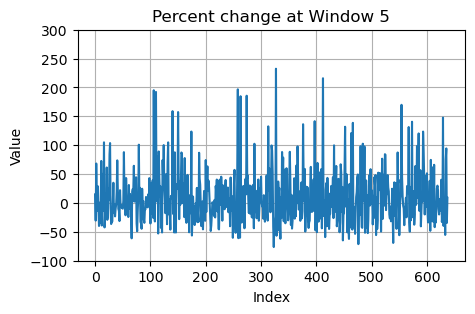

Number of percent samples: 638


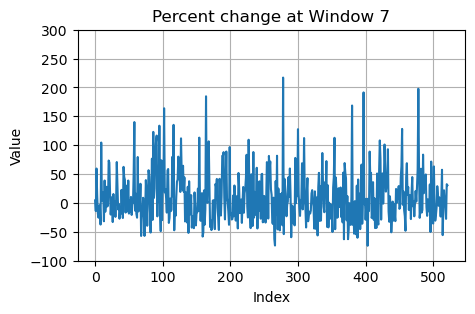

Number of percent samples: 522


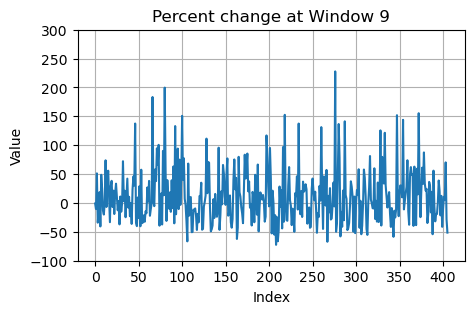

Number of percent samples: 406


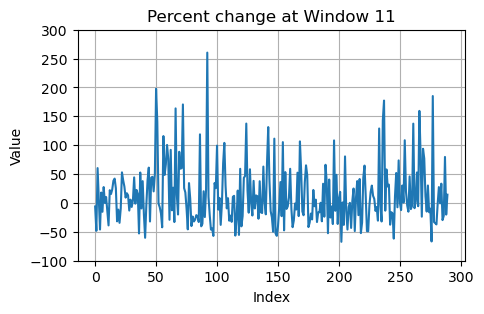

Number of percent samples: 290


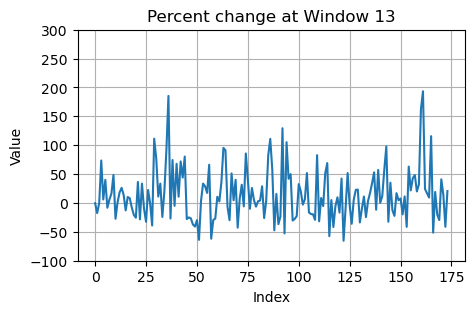

Number of percent samples: 174


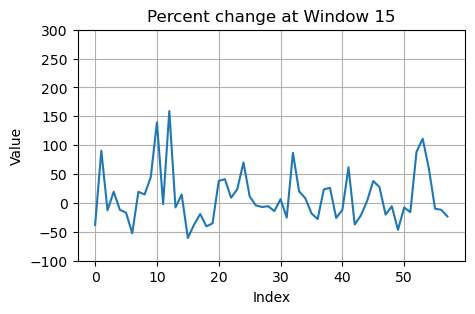

Number of percent samples: 58


In [365]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Clean up and remove outliers

In [366]:
std_dev = 2.5  # how many standard deviations from the mean data can be

# Replace outliers with median for each window
percent_dict_cleaned = {}

for window, percents in percent_dict.items():
    # Calculate z-scoresS
    mean = np.nanmean(percents)
    std = np.nanstd(percents)
    z_scores = (percents - mean) / std
    
    # Replace values with NaN if they're more than std_dev standard deviations from mean
    percents_masked = np.where(np.abs(z_scores) > std_dev, np.nan, percents)
    
    # Fill NaN with the median
    median = np.nanmedian(percents_masked)
    percents_cleaned = np.where(np.isnan(percents_masked), median, percents_masked)
    
    percent_dict_cleaned[window] = percents_cleaned
    
    # Optional: Print replacement statistics
    n_replaced = np.sum(np.abs(z_scores) > std_dev)
    pct_replaced = 100 * n_replaced / len(percents)
    print(f"Window {window}: Replaced {n_replaced} outliers ({pct_replaced:.1f}%) with median {median:.4f}")

# Use cleaned data for downstream analysis
percent_dict = percent_dict_cleaned

Window 3: Replaced 19 outliers (2.5%) with median -0.3717
Window 5: Replaced 18 outliers (2.8%) with median 0.3937
Window 7: Replaced 12 outliers (2.3%) with median 2.5166
Window 9: Replaced 14 outliers (3.4%) with median 3.4614
Window 11: Replaced 8 outliers (2.8%) with median -0.6652
Window 13: Replaced 4 outliers (2.3%) with median 6.9823
Window 15: Replaced 2 outliers (3.4%) with median -5.6447


#### Plot cleaned up percent changes

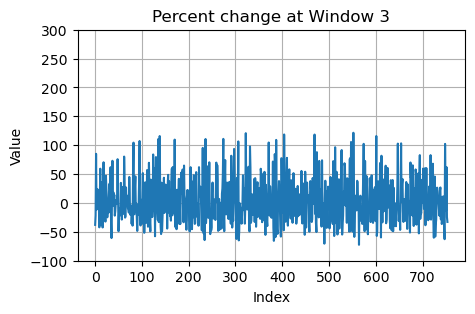

Number of percent samples: 754


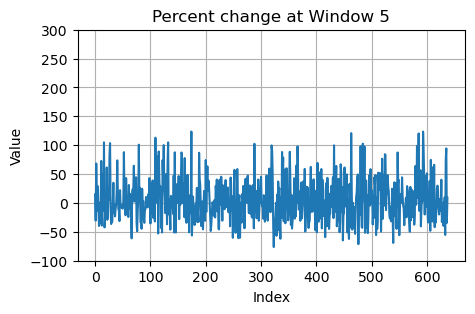

Number of percent samples: 638


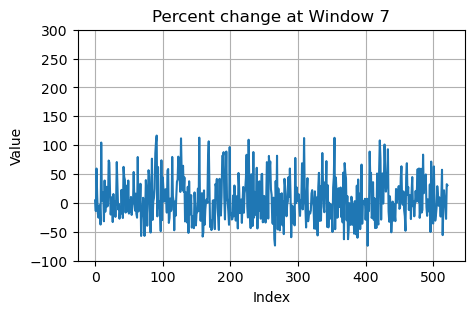

Number of percent samples: 522


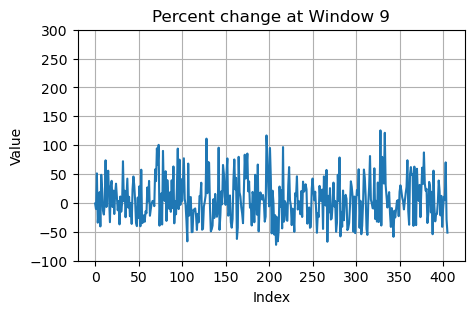

Number of percent samples: 406


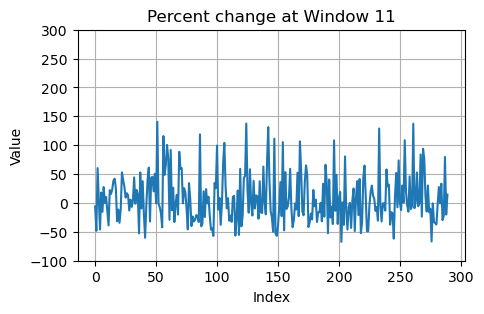

Number of percent samples: 290


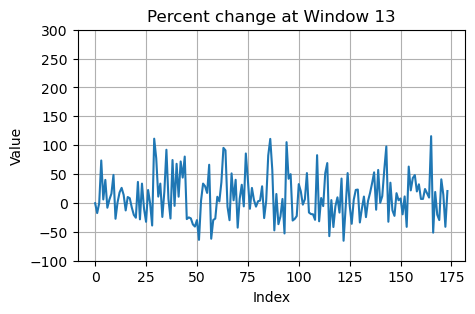

Number of percent samples: 174


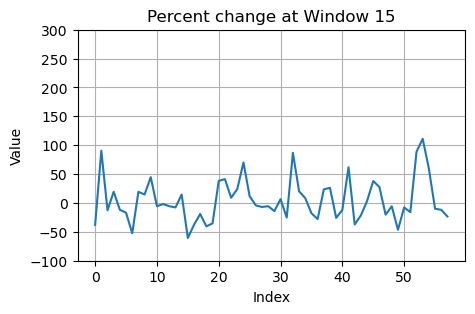

Number of percent samples: 58


In [367]:
for window, percent in percent_dict.items():
    plt.figure(figsize=(5, 3))
    plt.plot(range(len(percent)), percent)
    plt.title(f'Percent change at Window {window}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.ylim(-100, 300)
    plt.grid(True)
    plt.show()
    print("Number of percent samples:", len(percent))

### Ensure the data is normal at each window


Window 3:
  Shapiro-Wilk p = 4.3284e-12
  D'Agostino K² p = 5.3476e-11
Normality is statistically significant at 99% confidence.


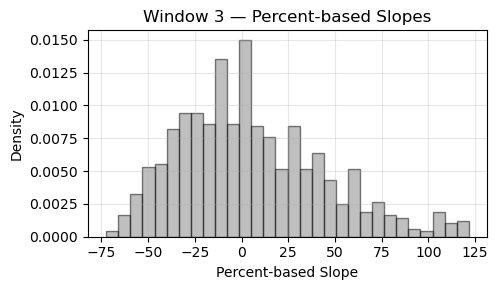


Window 5:
  Shapiro-Wilk p = 7.2534e-10
  D'Agostino K² p = 1.1575e-08
Normality is statistically significant at 99% confidence.


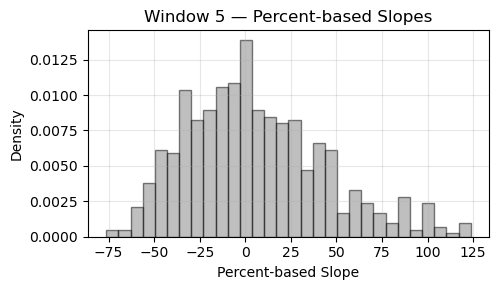


Window 7:
  Shapiro-Wilk p = 2.9425e-08
  D'Agostino K² p = 1.5919e-06
Normality is statistically significant at 99% confidence.


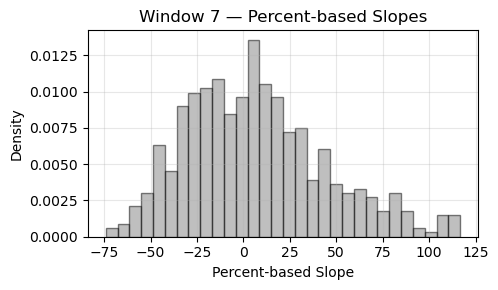


Window 9:
  Shapiro-Wilk p = 7.9038e-06
  D'Agostino K² p = 2.0584e-04
Normality is statistically significant at 99% confidence.


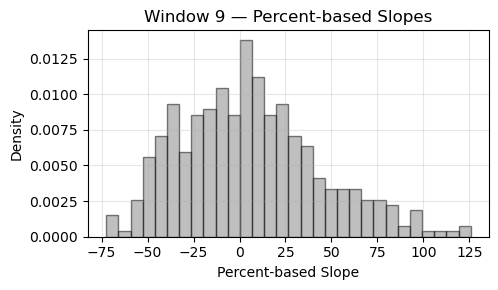


Window 11:
  Shapiro-Wilk p = 2.3040e-08
  D'Agostino K² p = 3.1001e-07
Normality is statistically significant at 99% confidence.


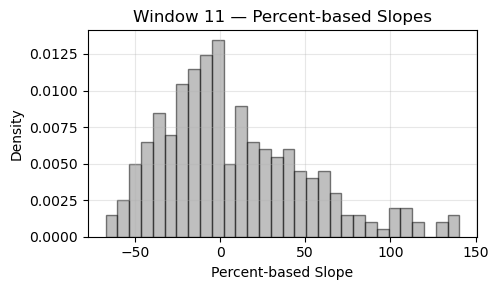


Window 13:
  Shapiro-Wilk p = 1.7501e-03
  D'Agostino K² p = 1.7861e-02
Normality is NOT statistically significant at 99% confidence.


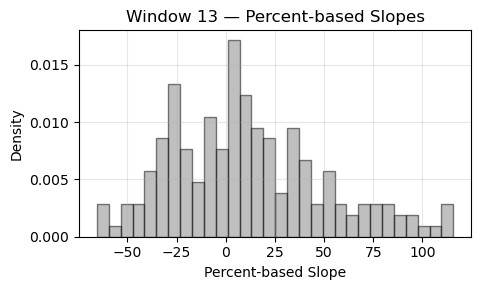


Window 15:
  Shapiro-Wilk p = 5.1070e-03
  D'Agostino K² p = 1.2739e-02
Normality is NOT statistically significant at 99% confidence.


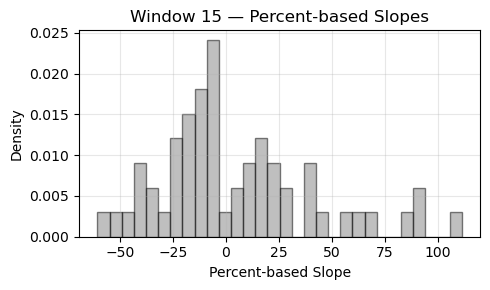

In [368]:
for window, data in percent_dict.items():
    # data = data[~np.isnan(data)]  # drop NaNs if any

    # run simple normality tests
    shapiro_stat, shapiro_p = shapiro(data[:5000])  # Shapiro max n=5000
    dagostino_stat, dagostino_p = normaltest(data)

    print(f"\nWindow {window}:")
    print(f"  Shapiro-Wilk p = {shapiro_p:.4e}")
    print(f"  D'Agostino K² p = {dagostino_p:.4e}")

    if (shapiro_p < 0.01 and dagostino_p < 0.01):
        print(Fore.GREEN + f"Normality is statistically significant at 99% confidence.") #figure out if two tailed or what
    else:
        print(Fore.RED + f"Normality is NOT statistically significant at 99% confidence.")

    # visualize histogram
    plt.figure(figsize=(5,3))
    plt.hist(data, bins=30, density=True, alpha=0.5, color='gray', edgecolor='black')
    plt.title(f"Window {window} — Percent-based Slopes")
    plt.xlabel("Percent-based Slope")
    plt.ylabel("Density")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Use Gaussian Mixture Model to label

## Find thresholds for given probability

In [369]:
desired_probability = 0.9

In [370]:
conf_percent = str(desired_probability * 100) + "%"
thresholds = {}
gmm_results = {}

for window, percent in percent_dict.items():
    percents_reshaped = percent.reshape(-1, 1) # reshape the percents
    gmm = BayesianGaussianMixture(n_components=3, n_init=100, tol=0.001) # create GMM
    gmm.fit(percents_reshaped) # fit the GMM to the data
    
    # sort components
    means = gmm.means_.flatten()

    sigmas = np.sqrt(gmm.covariances_.flatten())

    order = np.argsort(means)
    means, sigmas, weights = means[order], sigmas[order], gmm.weights_[order]
    
    # compute posteriors over value range
    x = np.linspace(np.min(percent), np.max(percent), 10000)
    # probability distribution function
    pdfs = np.array([w * norm.pdf(x, m, s) for w, m, s in zip(weights, means, sigmas)])
    posteriors = pdfs / np.sum(pdfs, axis=0)
    
    # confidence thresholds
    # learning group is index 0
    learning_cutoff = x[np.where(posteriors[0] >= desired_probability)[0][-1]] if np.any(posteriors[0] >= desired_probability) else np.nan
    # fatigue group is index 2
    fatigue_cutoff = x[np.where(posteriors[2] >= desired_probability)[0][0]] if np.any(posteriors[2] >= desired_probability) else np.nan

    thresholds[window] = {
        "learning_cutoff": learning_cutoff,
        "fatigue_cutoff": fatigue_cutoff,
        "means": means,
    }
    gmm_results[window] = {"means": means, "sigmas": sigmas, "weights": weights}

# display thresholds
for w, t in thresholds.items():
    print(f"Window {w}:")
    print(f"  {conf_percent} Learning cutoff: {t['learning_cutoff']:.4f}")
    print(f"  {conf_percent} Fatigue cutoff: {t['fatigue_cutoff']:.4f}")


Window 3:
  90.0% Learning cutoff: nan
  90.0% Fatigue cutoff: 83.9211
Window 5:
  90.0% Learning cutoff: -51.8910
  90.0% Fatigue cutoff: 75.9149
Window 7:
  90.0% Learning cutoff: -24.0685
  90.0% Fatigue cutoff: 52.4718
Window 9:
  90.0% Learning cutoff: -30.3519
  90.0% Fatigue cutoff: 54.7970
Window 11:
  90.0% Learning cutoff: -14.6381
  90.0% Fatigue cutoff: 84.7086
Window 13:
  90.0% Learning cutoff: -0.2906
  90.0% Fatigue cutoff: 68.8474
Window 15:
  90.0% Learning cutoff: 4.4574
  90.0% Fatigue cutoff: 59.8626


## Display GMM findings

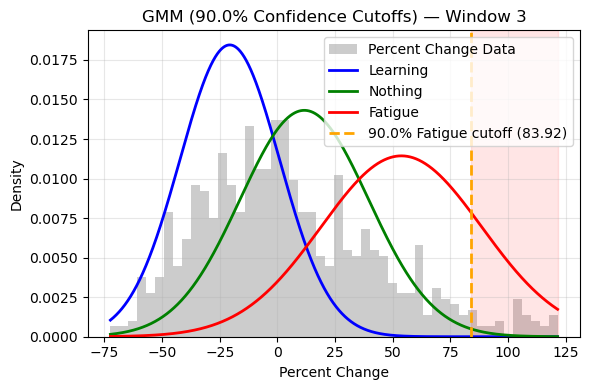

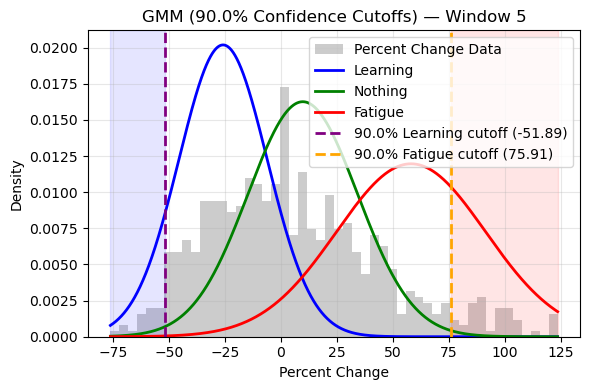

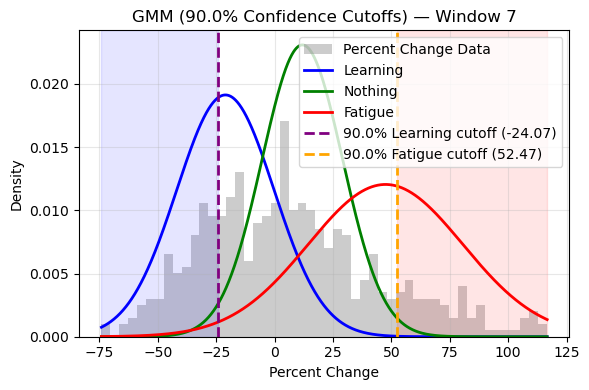

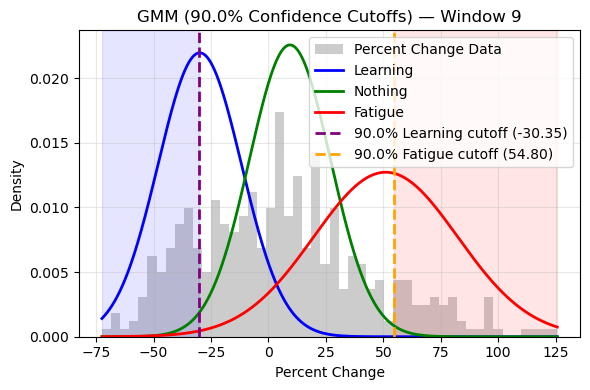

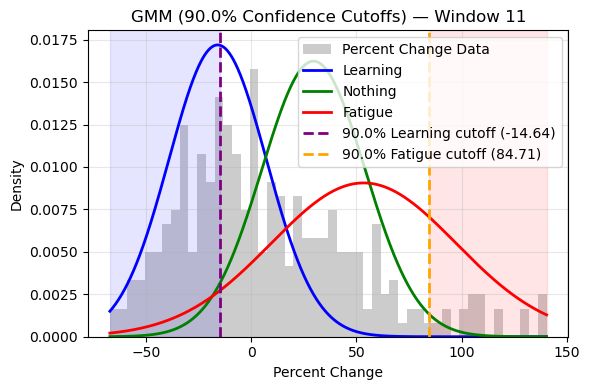

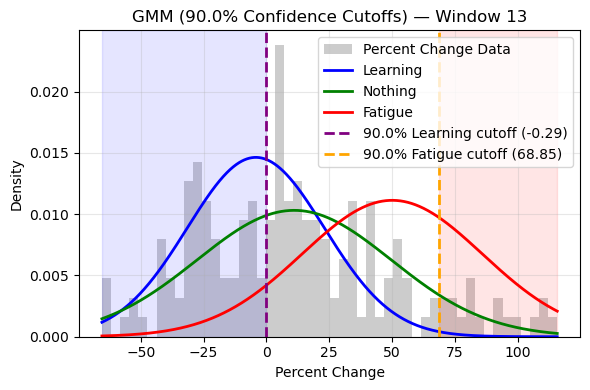

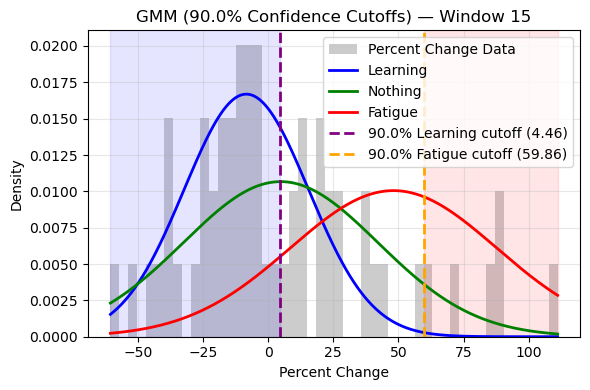

In [371]:
for window in window_sizes: 
    results = gmm_results[window]
    means = results["means"]
    sigmas = results["sigmas"]
    percents = percent_dict[window]

    # compute Gaussian PDFs
    x = np.linspace(np.nanmin(percents), np.nanmax(percents), 10000)
    pdfs = [norm.pdf(x, mu, sigma) for mu, sigma in zip(means, sigmas)]
    
    # extract confidence cutoffs
    t_learning = thresholds[window]["learning_cutoff"]
    t_fatigue = thresholds[window]["fatigue_cutoff"]

    # plot histogram
    plt.figure(figsize=(6, 4))
    plt.hist(percents, bins=50, density=True, alpha=0.4, color='gray', label='Percent Change Data')

    # plot Gaussians
    colors = ['blue', 'green', 'red']
    labels = ['Learning', 'Nothing', 'Fatigue']
    for pdf, color, label in zip(pdfs, colors, labels):
        plt.plot(x, pdf, color=color, lw=2, label=label)

    # shaded regions for high-confidence areas
    if not np.isnan(t_learning):
        plt.axvspan(x.min(), t_learning, color='blue', alpha=0.1)
    if not np.isnan(t_fatigue):
        plt.axvspan(t_fatigue, x.max(), color='red', alpha=0.1)

    # plot 90% confidence cutoffs
    if not np.isnan(t_learning):
        plt.axvline(t_learning, color='purple', linestyle='--', lw=2,
                    label=f'{conf_percent} Learning cutoff ({t_learning:.2f})')
    if not np.isnan(t_fatigue):
        plt.axvline(t_fatigue, color='orange', linestyle='--', lw=2,
                    label=f'{conf_percent} Fatigue cutoff ({t_fatigue:.2f})')

    
    plt.title(f"GMM ({conf_percent} Confidence Cutoffs) — Window {window}")
    plt.xlabel("Percent Change")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Ensure GMM thresholds are statistically significant

### H0 = The percent change at or beyond the calculated threshold is due to random variation

### H1 = The percent change at or beyond the calculated threshold is not due to random variation

In [372]:
for w, t in thresholds.items():
    print(Fore.CYAN + f"Window {w}: mean percent change is {statistics.mean(percent_dict[w])}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['learning_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Learning threshold = {t['learning_cutoff']:.4f} is statistically significant with a p-value of {p_value}") 
    else:
        print(Fore.RED + f"Learning threshold = {t['learning_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")
    t_stat, p_value = stats.ttest_1samp(percent_dict[w], t['fatigue_cutoff'])
    if (p_value < 0.001):
        print(Fore.GREEN + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is statistically significant with a p-value of {p_value}")
    else:
        print(Fore.RED + f"Fatigue threshold = {t['fatigue_cutoff']:.4f} is NOT statistically significant with a p-value of {p_value}")

Window 3: mean percent change is 4.934044109911264
Learning threshold = nan is NOT statistically significant with a p-value of nan
Fatigue threshold = 83.9211 is statistically significant with a p-value of 5.215640968619963e-270
Window 5: mean percent change is 5.563633168145752
Learning threshold = -51.8910 is statistically significant with a p-value of 2.0240675696403023e-165
Fatigue threshold = 75.9149 is statistically significant with a p-value of 1.5399800181207664e-206
Window 7: mean percent change is 6.746418688685622
Learning threshold = -24.0685 is statistically significant with a p-value of 1.5468086410152276e-59
Fatigue threshold = 52.4718 is statistically significant with a p-value of 6.454962462885214e-104
Window 9: mean percent change is 5.95577627865079
Learning threshold = -30.3519 is statistically significant with a p-value of 2.2802361147687516e-59
Fatigue threshold = 54.7970 is statistically significant with a p-value of 2.904698220915099e-88
Window 11: mean percent 

## Visualize thresholds in trials

### Prepare for visualization

In [375]:
window = 7 # size of window - user determined

In [376]:
learning_threshold = thresholds[window]["learning_cutoff"]
print(f"Learning threshold: {learning_threshold}")

fatigue_threshold = thresholds[window]["fatigue_cutoff"]
print(f"Fatigue threshold: {fatigue_threshold}")

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        
        start_val = errors[start]

        end_val = errors[start + window - 1]

        percent_changed = get_change(start_val, end_val)

        if percent_changed < learning_threshold:
            subject_modes.append("learning")
        elif percent_changed > fatigue_threshold:
            subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

Learning threshold: -24.068507524859932
Fatigue threshold: 52.47183766237397


### Visualize at given window

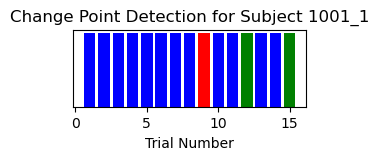

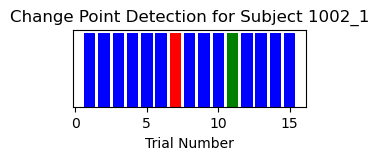

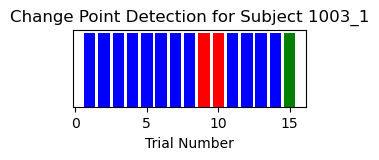

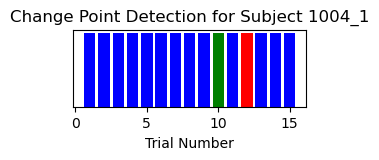

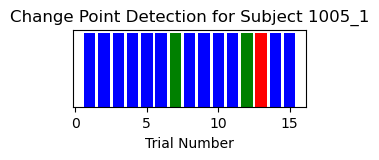

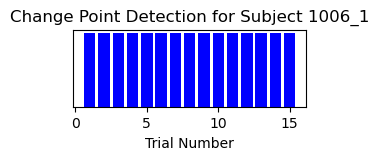

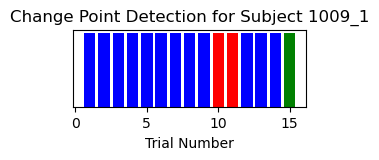

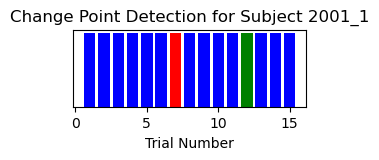

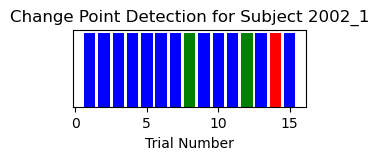

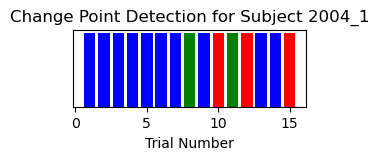

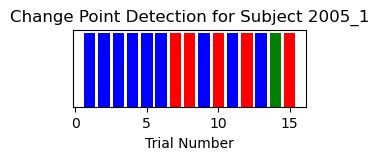

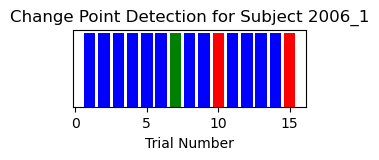

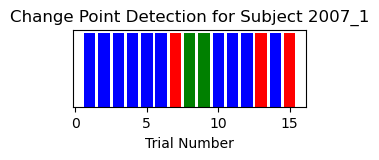

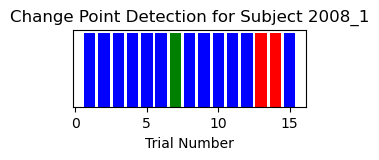

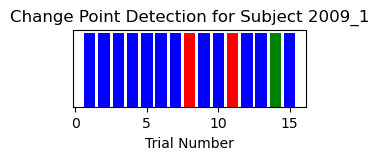

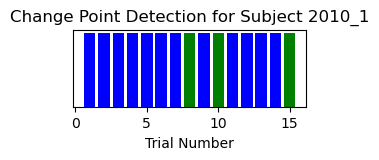

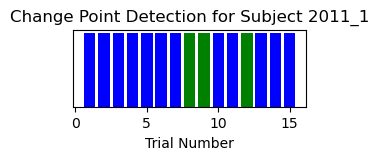

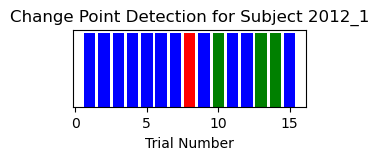

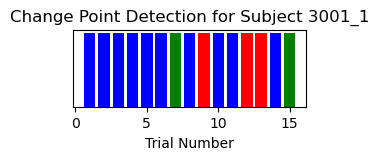

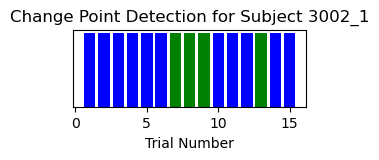

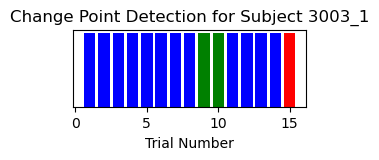

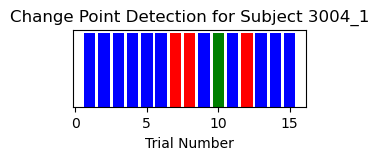

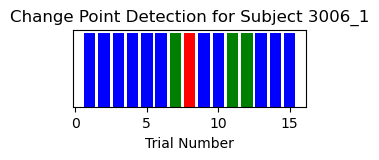

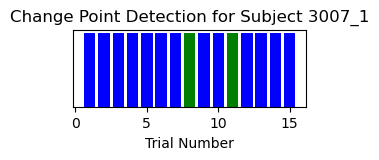

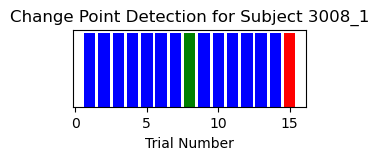

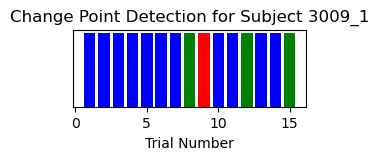

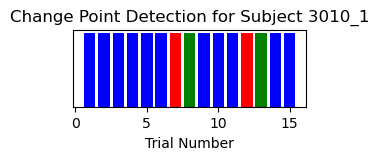

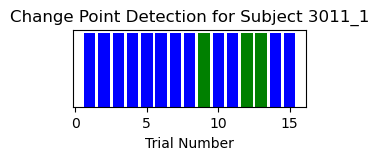

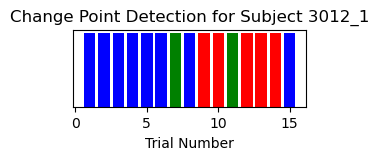

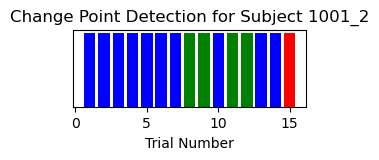

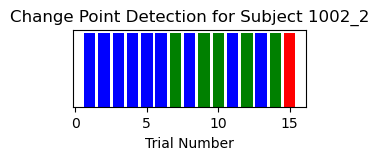

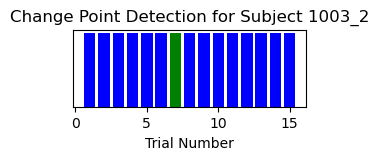

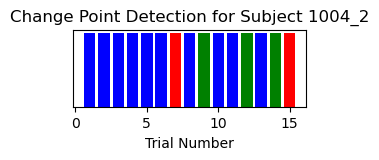

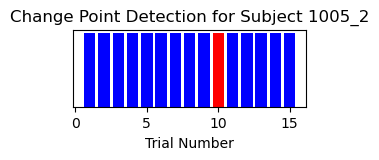

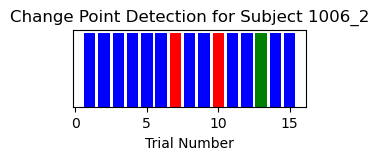

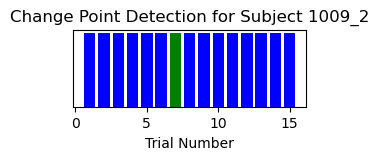

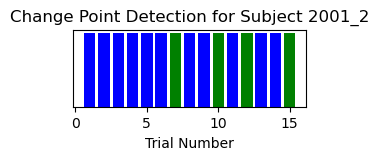

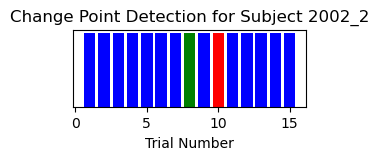

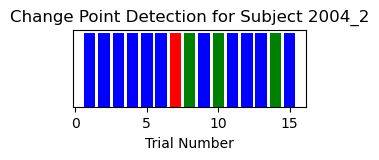

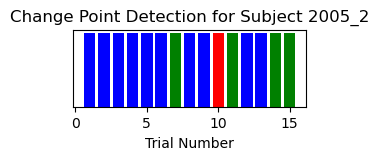

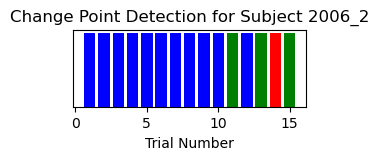

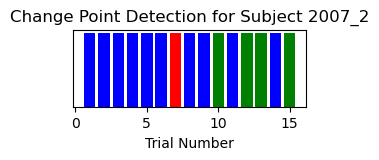

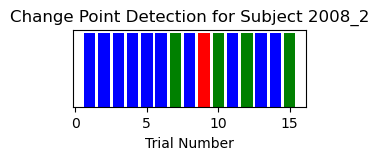

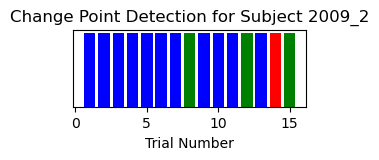

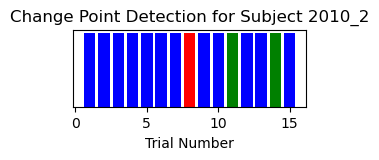

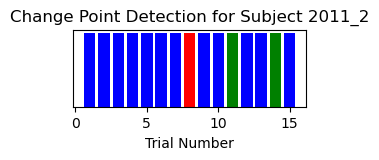

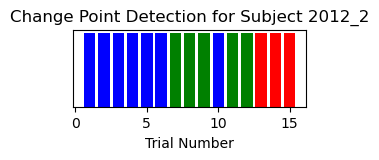

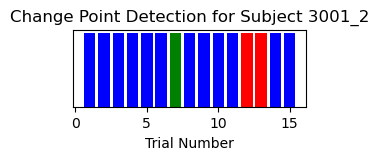

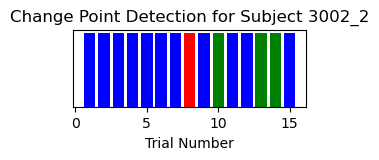

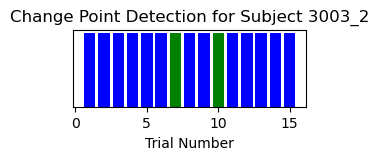

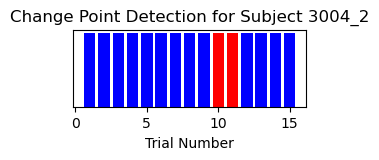

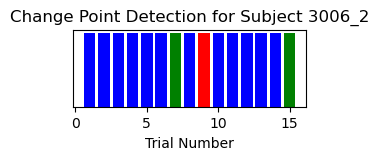

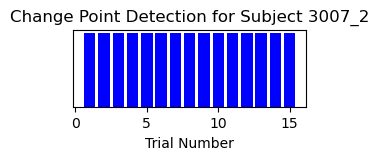

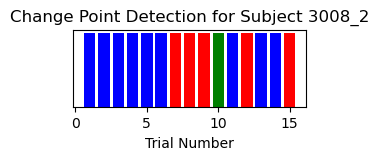

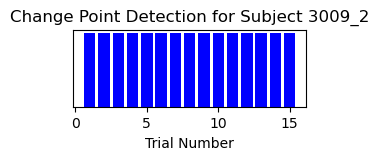

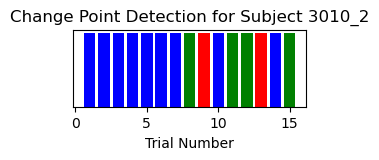

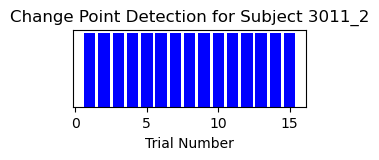

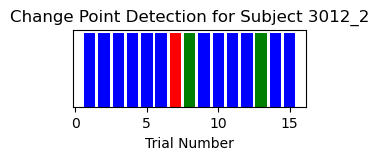

In [377]:
for i in range(0,raw_df.shape[0]):
    subject = i
    colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(3,1))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()